# EDA: PetFinder, швидкість адопції

Розвідка даних перед моделюванням: цільова змінна, тексти описів, фото, особливості PetID і дублікати описів. У кінці короткі висновки, що з цього випливає для моделей.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import cohen_kappa_score

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 160)

# локально ноутбук лежить у Final_Project/, дані поруч у Data/; у Colab тягну їх з Kaggle
DATA_DIR = Path("Data")
if not (DATA_DIR / "train.csv").exists():
    import kagglehub
    DATA_DIR = Path(kagglehub.competition_download("deep-learning-for-computer-vision-and-nlp-2026-10"))

CSV_DIR = next(DATA_DIR.rglob("train.csv")).parent


def find_img_dir(root, name):
    # папка з фото може лежати на різній глибині, беру каталог з такою назвою, у якому є jpg
    return next(p for p in root.rglob(name) if p.is_dir() and any(p.glob("*.jpg")))


TRAIN_IMG = find_img_dir(DATA_DIR, "train")
TEST_IMG = find_img_dir(DATA_DIR, "test")

FIG_DIR = Path("Results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CSV_DIR, TRAIN_IMG, TEST_IMG, sep="\n")

Data
Data/images/images/train
Data/images/images/test


## Дані

Лише три колонки: PetID, Description, AdoptionSpeed (1 - найшвидша адопція, 4 - найповільніша). PetID читаю як рядок, бо в ньому бувають провідні нулі (деталі нижче). sample_submission.csv - це тільки приклад формату на 4 рядки.

train: (6431, 3)  test: (1891, 2)  sample_submission: (4, 2)
NaN train: {'PetID': 0, 'Description': 5, 'AdoptionSpeed': 0}
NaN test: {'PetID': 0, 'Description': 1}


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,"Mayleen and Flo are two lovely adorable sisters. They are very friendly and affectionate, but wary of strangers and make good watchdogs. Mayleen has golden ...",2
1,e9dc82251,"A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and p...",2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and cute.,2


,n,"частка, %"
AdoptionSpeed,,
1,1197,18.6
2,1773,27.6
3,1328,20.6
4,2133,33.2


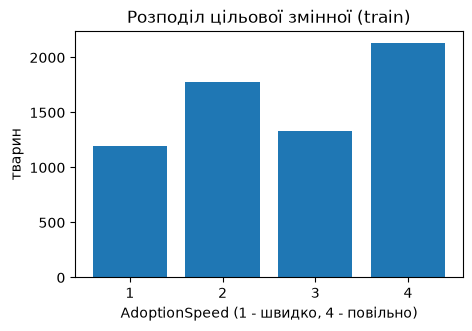

In [2]:
train = pd.read_csv(CSV_DIR / "train.csv", dtype={"PetID": str})
test = pd.read_csv(CSV_DIR / "test.csv", dtype={"PetID": str})
sub = pd.read_csv(CSV_DIR / "sample_submission.csv", dtype={"PetID": str})
print("train:", train.shape, " test:", test.shape, " sample_submission:", sub.shape)
print("NaN train:", train.isna().sum().to_dict())
print("NaN test:", test.isna().sum().to_dict())
display(train.head(3))

target = train.AdoptionSpeed.value_counts().sort_index()
display(pd.DataFrame({"n": target, "частка, %": (100 * target / len(train)).round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(target.index.astype(str), target.values, color="tab:blue")
ax.set_xlabel("AdoptionSpeed (1 - швидко, 4 - повільно)")
ax.set_ylabel("тварин")
ax.set_title("Розподіл цільової змінної (train)")
plt.savefig(FIG_DIR / "eda_target.png", dpi=120, bbox_inches="tight")
plt.show()

Дисбаланс помірний: найбільший клас 4 (33 %), найменший клас 1 (19 %). Метрика змагання - quadratic weighted kappa (QWK): помилка на сусідній клас карається слабше, ніж на далекий, тому порядок класів має значення і задачу можна розглядати як регресію з порогами.

## Описи

порожніх описів: train 5  test 1
слів в описі (train): {'count': 6431.0, 'mean': 67.4, 'std': 76.1, 'min': 0.0, '25%': 22.0, '50%': 46.0, '75%': 85.0, 'max': 1153.0}


,median,mean,max
AdoptionSpeed,,,
1,49.0,68.5,1153
2,46.0,68.7,870
3,50.5,71.7,936
4,43.0,63.2,789


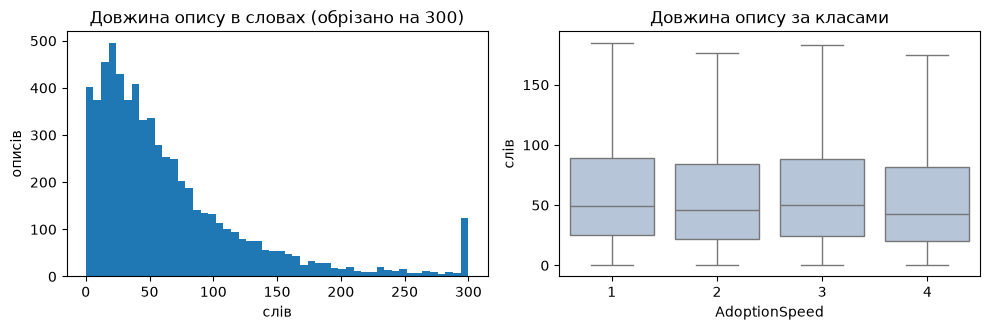

In [3]:
for df in (train, test):
    df["Description"] = df.Description.fillna("")
    df["n_words"] = df.Description.str.split().str.len()

print("порожніх описів: train", int((train.n_words == 0).sum()), " test", int((test.n_words == 0).sum()))
print("слів в описі (train):", train.n_words.describe().round(1).to_dict())
display(train.groupby("AdoptionSpeed").n_words.agg(["median", "mean", "max"]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(train.n_words.clip(upper=300), bins=50, color="tab:blue")
axes[0].set_title("Довжина опису в словах (обрізано на 300)")
axes[0].set_xlabel("слів")
axes[0].set_ylabel("описів")
sns.boxplot(x="AdoptionSpeed", y="n_words", data=train, showfliers=False, color="lightsteelblue", ax=axes[1])
axes[1].set_title("Довжина опису за класами")
axes[1].set_xlabel("AdoptionSpeed")
axes[1].set_ylabel("слів")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_desc_len.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
samples = train[train.n_words > 0].groupby("AdoptionSpeed").sample(2, random_state=SEED)
display(samples[["AdoptionSpeed", "n_words", "Description"]].assign(Description=samples.Description.str.slice(0, 160)))

# частина описів малайською або змішана, перевіряю на кількох частих словах
malay_words = ["manja", "comel", "kucing", "anjing", "sihat", "jantan", "betina", "untuk", "sangat"]
low = train.Description.str.lower()
print("описів зі словом:", {w: int(low.str.contains(rf"\b{w}\b").sum()) for w in malay_words})
any_malay = low.str.contains(r"\b(?:" + "|".join(malay_words) + r")\b")
print(f"хоча б одне з них: {int(any_malay.sum())} ({100 * any_malay.mean():.1f} %)")

# шум у тексті: посилання, китайські ієрогліфи, емодзі, довгі повтори пунктуації
# діапазони через chr(), бо рушій регулярок у pandas з pyarrow не розуміє \u-екранування
patterns = {"посилання": r"https?://|www\.", "ієрогліфи": f"[{chr(0x4E00)}-{chr(0x9FFF)}]",
            "емодзі": f"[{chr(0x1F300)}-{chr(0x1FAFF)}{chr(0x2600)}-{chr(0x27BF)}]", "3+ знаки пунктуації підряд": r"[!?.]{3,}"}
print("описів із шумом:", {k: int(train.Description.str.contains(pat, regex=True).sum()) for k, pat in patterns.items()})

,AdoptionSpeed,n_words,Description
4169,1,67,"I am putting this up for my neighbour, Aunty Aisyah. She's very caring about animals. She helps the strays and feeds them very good food. 4 kittens were bor..."
1671,1,13,"Blue eyes, playful, still milking from mother. Soon will be able to adopt."
3664,2,128,Location: Puchong (Bandar Kinrara) Hi I'm Momo! I'm a highly intelligent kitten that is very attached to people. I love to get myself cosy on people's lap. ...
4298,2,16,cute active healthy puppy for adpotion location balakong jaya..serdang.. tis puppies found at serdang industry park.
4613,3,3,Love my furkids..
2302,3,40,3 male and 1 female puppies for adoption. Their mother was spayed just after it gave birth to these puppies. I have 3 dogs in my house now. I am unable to t...
3122,4,22,Something about Dixie that will keep your heart warm. She likes to play yet an independent cat. Contact on WhatsApp only at.
1883,4,36,"3 puppies looking for home in Subang 2 2 Male, 1 female I can’t keep them as my house already have 2 dogs and my neighbors are complaining. Hope can get the..."


описів зі словом: {'manja': 286, 'comel': 38, 'kucing': 113, 'anjing': 19, 'sihat': 21, 'jantan': 21, 'betina': 14, 'untuk': 66, 'sangat': 58}


хоча б одне з них: 408 (6.3 %)
описів із шумом: {'посилання': 20, 'ієрогліфи': 81, 'емодзі': 110, '3+ знаки пунктуації підряд': 597}


## Фото

Файли названі `<PetID>-<номер>.jpg`, нумерація з 1 і без пропусків, тож індекс фото будую просто з імен файлів.

фото: train 28472  test 9448
перше фото завжди має номер 1: True
нумерація без пропусків: True


,PetID,photo_no,file
0,000a290e4,1,000a290e4-1.jpg
1,000a290e4,2,000a290e4-2.jpg
2,000fb9572,1,000fb9572-1.jpg


тварин без фото в train: 0
фото на тварину: {'count': 6431.0, 'mean': 4.43, 'std': 3.88, 'min': 1.0, '25%': 2.0, '50%': 4.0, '75%': 5.0, 'max': 30.0}


,mean,median,max
AdoptionSpeed,,,
1,4.18,4.0,30
2,4.73,4.0,30
3,5.38,4.0,30
4,3.72,3.0,30


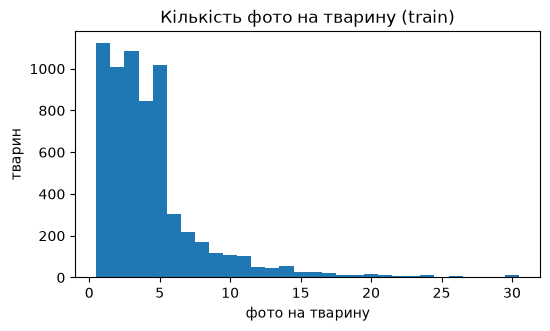

In [5]:
def photo_index(img_dir):
    rows = []
    for p in img_dir.glob("*.jpg"):
        pet_id, no = p.stem.rsplit("-", 1)
        rows.append((pet_id, int(no), p.name))
    return pd.DataFrame(rows, columns=["PetID", "photo_no", "file"]).sort_values(["PetID", "photo_no"]).reset_index(drop=True)


photos_train = photo_index(TRAIN_IMG)
photos_test = photo_index(TEST_IMG)
print("фото: train", len(photos_train), " test", len(photos_test))
print("перше фото завжди має номер 1:", bool((photos_train.groupby("PetID").photo_no.min() == 1).all()))
numbering = photos_train.groupby("PetID").photo_no.agg(["max", "count"])
print("нумерація без пропусків:", bool((numbering["max"] == numbering["count"]).all()))
display(photos_train.head(3))

train["n_photos"] = train.PetID.map(photos_train.groupby("PetID").size()).fillna(0).astype(int)
print("тварин без фото в train:", int((train.n_photos == 0).sum()))
print("фото на тварину:", train.n_photos.describe().round(2).to_dict())
display(train.groupby("AdoptionSpeed").n_photos.agg(["mean", "median", "max"]).round(2))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(train.n_photos, bins=np.arange(0.5, 31.5, 1), color="tab:blue")
ax.set_xlabel("фото на тварину")
ax.set_ylabel("тварин")
ax.set_title("Кількість фото на тварину (train)")
plt.savefig(FIG_DIR / "eda_photos_per_pet.png", dpi=120, bbox_inches="tight")
plt.show()

,w,h,aspect
count,500.00,500.00,500.00
mean,400.79,399.36,1.05
std,125.95,90.83,0.36
min,127.00,194.00,0.43
25%,300.00,300.00,0.75
50%,400.00,400.00,1.00
75%,400.00,480.00,1.33
max,640.00,640.00,1.85


режими: {'RGB': 500}


найчастіші розміри (w, h): {(400, 300): 92, (360, 480): 68, (300, 400): 55, (640, 480): 38, (270, 480): 25}


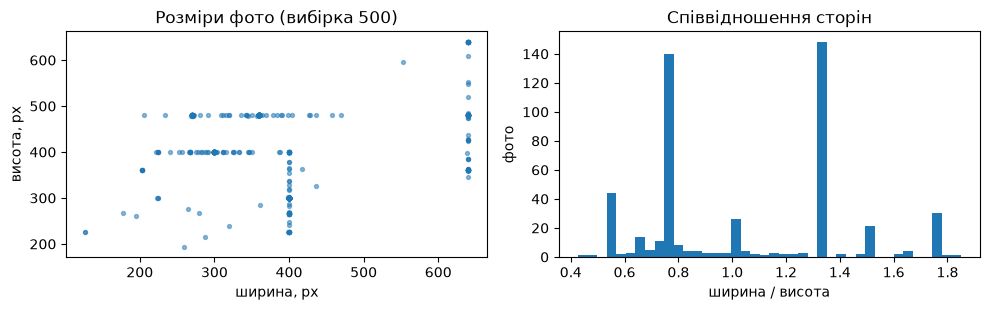

In [6]:
rng = np.random.default_rng(SEED)
sample_files = rng.choice(photos_train.file.tolist(), size=500, replace=False)
rows = []
for f in sample_files:
    # PIL читає лише заголовок, пікселі не декодуються, тому це швидко
    with Image.open(TRAIN_IMG / f) as im:
        rows.append((im.width, im.height, im.mode))
img_sizes = pd.DataFrame(rows, columns=["w", "h", "mode"])
img_sizes["aspect"] = img_sizes.w / img_sizes.h
display(img_sizes[["w", "h", "aspect"]].describe().round(2))
print("режими:", img_sizes["mode"].value_counts().to_dict())
print("найчастіші розміри (w, h):", img_sizes.groupby(["w", "h"]).size().sort_values(ascending=False).head(5).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].scatter(img_sizes.w, img_sizes.h, s=8, alpha=0.5)
axes[0].set_xlabel("ширина, px")
axes[0].set_ylabel("висота, px")
axes[0].set_title("Розміри фото (вибірка 500)")
axes[1].hist(img_sizes.aspect, bins=40, color="tab:blue")
axes[1].set_xlabel("ширина / висота")
axes[1].set_ylabel("фото")
axes[1].set_title("Співвідношення сторін")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_img_sizes.png", dpi=120, bbox_inches="tight")
plt.show()

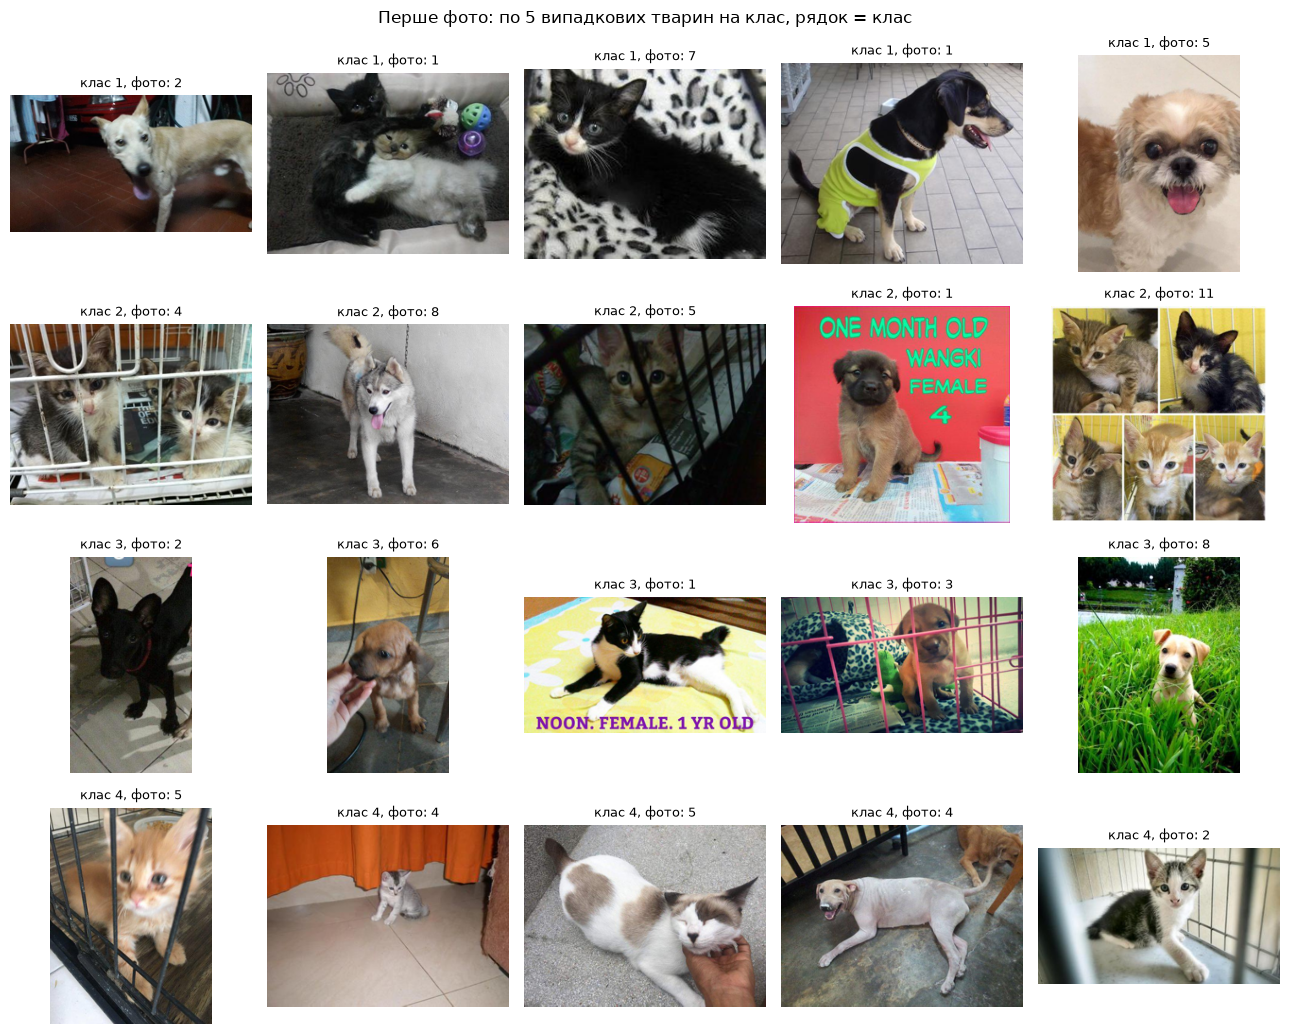

In [7]:
n_photos_by_id = train.set_index("PetID").n_photos

fig, axes = plt.subplots(4, 5, figsize=(13, 10.5))
for row, cls in enumerate([1, 2, 3, 4]):
    ids = train.loc[train.AdoptionSpeed == cls, "PetID"].sample(5, random_state=SEED)
    for ax, pet_id in zip(axes[row], ids):
        with Image.open(TRAIN_IMG / f"{pet_id}-1.jpg") as im:
            im = im.convert("RGB")
            im.thumbnail((256, 256))
            arr = np.asarray(im)
        ax.imshow(arr)
        ax.set_title(f"клас {cls}, фото: {n_photos_by_id[pet_id]}", fontsize=9)
        ax.axis("off")
plt.suptitle("Перше фото: по 5 випадкових тварин на клас, рядок = клас")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_photo_grid.png", dpi=120, bbox_inches="tight")
plt.show()

## Особливість PetID у test

Чотири PetID у test.csv мають 8 символів замість 9: вони складаються лише з цифр, і провідний нуль загубився, коли id зберегли як число. У файлах фото id повний, тому фото шукаю за `PetID.str.zfill(9)`, а в submission лишаю PetID як у test.csv. Ще 8 id фото не мають рядка в test.csv (усі схожі на числа в експоненційному записі, типу 2514503e7), їх просто ігнорую.

In [8]:
print("довжина PetID: train", train.PetID.str.len().value_counts().to_dict(), " test", test.PetID.str.len().value_counts().to_dict())
short_ids = test.loc[test.PetID.str.len() < 9, "PetID"].tolist()
test_photo_ids = set(photos_test.PetID)
for pid in short_ids:
    print(f"{pid}: фото за raw id - {pid in test_photo_ids}, за zfill(9) '{pid.zfill(9)}' - {pid.zfill(9) in test_photo_ids}")

test_ids_z = test.PetID.str.zfill(9)
print("test рядків без фото після zfill:", int((~test_ids_z.isin(test_photo_ids)).sum()))
orphans = sorted(test_photo_ids - set(test_ids_z))
print(f"id фото без рядка в test.csv: {len(orphans)}", orphans)
print("PetID із sample_submission є в test.csv як є:", bool(sub.PetID.isin(test.PetID).all()))

довжина PetID: train {9: 6431}  test {9: 1887, 8: 4}
95314294: фото за raw id - False, за zfill(9) '095314294' - True
35992662: фото за raw id - False, за zfill(9) '035992662' - True
63521459: фото за raw id - False, за zfill(9) '063521459' - True
81301773: фото за raw id - False, за zfill(9) '081301773' - True
test рядків без фото після zfill: 0
id фото без рядка в test.csv: 8 ['02126e289', '2514503e7', '2689341e7', '515462e67', '554965e66', '670535e94', '7759517e2', '867057e77']
PetID із sample_submission є в test.csv як є: True


## Дублікати описів

Один і той самий текст часто повторюється для різних тварин, схоже, притулки публікують серію оголошень з одним описом. Перевіряю, чи збігаються мітки всередині таких груп і чи трапляються тексти з train у test.

In [9]:
norm_train = train.Description.str.lower().str.strip()
norm_test = test.Description.str.lower().str.strip()
has_text = norm_train != ""

group_sizes = norm_train[has_text].value_counts()
dup_keys = group_sizes[group_sizes > 1].index
in_dup = has_text & norm_train.isin(dup_keys)
print(f"рядків у групах-дублікатах: {int(in_dup.sum())}, груп: {len(dup_keys)}, найбільша група: {int(group_sizes.max())}")

dup = train.loc[in_dup, ["PetID", "AdoptionSpeed"]].assign(key=norm_train[in_dup])
labels_per_group = dup.groupby("key").AdoptionSpeed.nunique()
print(f"груп з однією міткою: {(labels_per_group == 1).mean():.3f}")


# мітка рядка за більшістю серед його дублікатів, сам рядок із підрахунку виключаю;
# нічию розриваю випадково, інакше порядок value_counts підказував би власну мітку
rng = np.random.default_rng(SEED)


def loo_majority(y):
    preds = []
    for i in y.index:
        c = y.drop(i).value_counts()
        preds.append(rng.choice(c[c == c.max()].index))
    return pd.Series(preds, index=y.index)


dup["pred"] = dup.groupby("key").AdoptionSpeed.transform(loo_majority).astype(int)
acc = (dup.pred == dup.AdoptionSpeed).mean()
qwk = cohen_kappa_score(dup.AdoptionSpeed, dup.pred, weights="quadratic")
base = (dup.AdoptionSpeed == train.AdoptionSpeed.mode()[0]).mean()
print(f"точність за мітками дублікатів: {acc:.3f} (QWK {qwk:.3f}), найчастіший клас на тих самих рядках: {base:.3f}")

for text, n in group_sizes.head(3).items():
    labels = dup.loc[dup.key == text, "AdoptionSpeed"].value_counts().to_dict()
    print(f"n={n}, мітки {labels}: {text[:90]}...")

test_in_train = (norm_test != "") & norm_test.isin(set(norm_train[has_text]))
print(f"описів test, що дослівно є в train: {int(test_in_train.sum())} з {len(test)}")

рядків у групах-дублікатах: 427, груп: 115, найбільша група: 73
груп з однією міткою: 0.687
точність за мітками дублікатів: 0.656 (QWK 0.669), найчастіший клас на тих самих рядках: 0.290
n=73, мітки {3: 29, 2: 28, 1: 14, 4: 2}: for adoption...
n=21, мітки {2: 8, 4: 7, 3: 6}: dog 4 adoption...
n=12, мітки {2: 7, 3: 3, 1: 2}: cat for adoption...
описів test, що дослівно є в train: 133 з 1891


## Дублікати фото

Те саме для фото: однакові файли (збіг md5) у різних оголошень, у тому числі між train і test.

In [10]:
import hashlib


def file_hashes(img_dir, split):
    rows = [(p.name, hashlib.md5(p.read_bytes()).hexdigest()) for p in img_dir.glob("*.jpg")]
    return pd.DataFrame(rows, columns=["file", "md5"]).assign(split=split)


hashes = pd.concat([file_hashes(TRAIN_IMG, "train"), file_hashes(TEST_IMG, "test")], ignore_index=True)
hashes["PetID"] = hashes.file.str.rsplit("-", n=1).str[0]
per_hash = hashes.groupby("md5").agg(pets=("PetID", "nunique"), splits=("split", "nunique"))
shared = per_hash[per_hash.pets > 1]
print(f"унікальних фото: {len(per_hash)}, спільних для кількох тварин: {len(shared)}, з них і в train, і в test: {int((shared.splits == 2).sum())}")

dup_photo = hashes[hashes.md5.isin(shared.index)].drop_duplicates(["md5", "PetID"])
print("тварин зі спільним фото:", dup_photo.groupby("split").PetID.nunique().to_dict())
train_md5 = set(dup_photo.loc[dup_photo.split == "train", "md5"])
print("тварин test, у яких є фото з train:", dup_photo[(dup_photo.split == "test") & dup_photo.md5.isin(train_md5)].PetID.nunique())

labels = train.set_index("PetID").AdoptionSpeed
photo_groups = dup_photo[dup_photo.split == "train"].assign(y=lambda d: d.PetID.map(labels)).groupby("md5").y.agg(["nunique", "count"])
photo_groups = photo_groups[photo_groups["count"] > 1]
print(f"груп train зі спільним фото: {len(photo_groups)}, з однією міткою: {(photo_groups['nunique'] == 1).mean():.3f}")

унікальних фото: 36992, спільних для кількох тварин: 396, з них і в train, і в test: 172
тварин зі спільним фото: {'test': 120, 'train': 317}
тварин test, у яких є фото з train: 95
груп train зі спільним фото: 218, з однією міткою: 0.711


## Train проти test

Міток у test немає, тож порівнюю лише те, що є в обох: довжину опису і кількість фото.

,train,test
"слів, медіана",46.000,49.000
"слів, середнє",67.442,69.315
частка порожніх описів,0.001,0.001
"фото, середнє",4.427,4.959
"фото, медіана",4.000,4.000
"фото, максимум",30.000,30.000


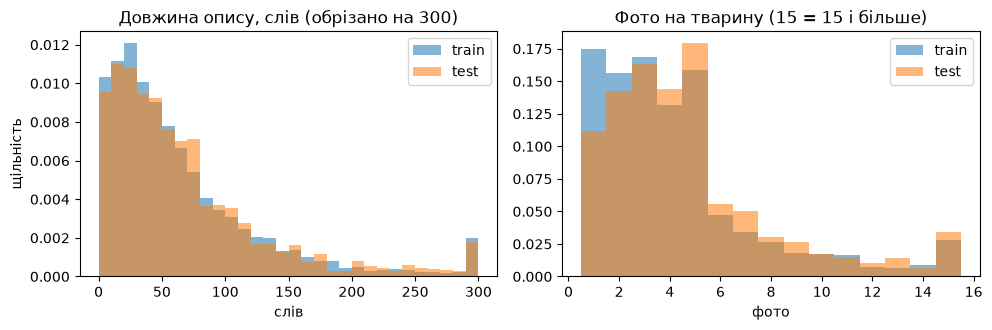

In [11]:
test["n_photos"] = test_ids_z.map(photos_test.groupby("PetID").size()).fillna(0).astype(int)

compare = pd.DataFrame(
    {
        "train": [train.n_words.median(), train.n_words.mean(), (train.n_words == 0).mean(), train.n_photos.mean(), train.n_photos.median(), train.n_photos.max()],
        "test": [test.n_words.median(), test.n_words.mean(), (test.n_words == 0).mean(), test.n_photos.mean(), test.n_photos.median(), test.n_photos.max()],
    },
    index=["слів, медіана", "слів, середнє", "частка порожніх описів", "фото, середнє", "фото, медіана", "фото, максимум"],
).round(3)
display(compare)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for name, df in [("train", train), ("test", test)]:
    axes[0].hist(df.n_words.clip(upper=300), bins=np.arange(0, 310, 10), density=True, alpha=0.55, label=name)
    axes[1].hist(df.n_photos.clip(upper=15), bins=np.arange(0.5, 16.5, 1), density=True, alpha=0.55, label=name)
axes[0].set_title("Довжина опису, слів (обрізано на 300)")
axes[0].set_xlabel("слів")
axes[0].set_ylabel("щільність")
axes[0].legend()
axes[1].set_title("Фото на тварину (15 = 15 і більше)")
axes[1].set_xlabel("фото")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_train_vs_test.png", dpi=120, bbox_inches="tight")
plt.show()

## Висновки для моделювання

Цільова змінна порядкова, а QWK карає далекі помилки сильніше за близькі. Тому природніше вчити регресію або
порядкову модель і підбирати пороги округлення під QWK на валідації. Дисбаланс класів помірний (від 19 до 33 %),
ваги класів окремо перевірю, але великого ефекту не чекаю.

Табличних ознак у датасеті немає, головне джерело інформації - фото. Їх у середньому 4.4 на тварину, тож варто
брати ембеддинги всіх фото й агрегувати по тварині, а не лише перше. Сама кількість фото теж ознака: у класу 4
їх найменше (3.7 у середньому проти 5.4 у класу 3).

Текст другорядний: медіана 46 слів, довжина за класами майже однакова, 5 порожніх описів. Шуму мало (посилання у 20
описах, ієрогліфи у 81, емодзі у 110), тому текст піде в токенізатори без чистки. Беру ембеддинги опису, прості
статистики тексту навряд чи щось дадуть.

Повторювані описи - це серії оголошень, з однаковою міткою приблизно у 69 % груп. Мітка за більшістю дублікатів
вгадує клас у 66 % випадків проти 29 % для найчастішого класу, хоча найбільші групи - це короткі
шаблонні тексти типу "for adoption" з мішаними мітками, а однакові мітки частіше в малих групах з довшим текстом.
Те саме з фото: 396 файлів повторюються в різних оголошень, у 71 % таких груп train мітка одна, а 95 тварин test
мають фото, яке є в train. Тому дублікати лишаю, а мітки найближчих сусідів у train (за текстом і за фото) стануть
сильною ознакою. 133 тексти з test є в train дослівно.

Фото шукаю за PetID.str.zfill(9), у submission PetID лишаю як у test.csv. Розподіли train і test за довжиною
тексту і кількістю фото близькі (у test трохи більше фото, 5.0 проти 4.4 у середньому, медіани однакові), тож
валідаційні оцінки мають переноситися на test.